# Understanding Backpropagation From Scratch
### No libraries. No matrices. Just plain Python numbers and the chain rule.

---

**What this notebook builds, step by step:**

```
Step 1 — A single node that remembers one operation
Step 2 — Two nodes chained together (chain rule in action)
Step 3 — Enough to compute:  output = x * w + b   (one neuron)
Step 4 — Train that neuron to actually learn something
```

By the end you will see exactly where the "magic" in backpropagation comes from.
It is not magic — it is just the chain rule applied to a remembered list of operations.

---
## Step 1 — The Core Problem: Why Do We Need a Graph at All?

You already know we want to minimize a loss by computing gradients.
The chain rule lets us do that. But here's the practical problem:

**The chain rule needs to remember what happened.**

Look at what you computed earlier:
```
dL/dx  where  L = (x * w)²

Answer: 2*(x*w) * w
```

To get that answer you needed to know:
- Step 1 was a multiply:  `y = x * w`
- Step 2 was a square:    `L = y²`
- AND you needed the value of `w` (the other input to the multiply)

If Python just computed `L = 4.0` and forgot everything, you could never backprop.
**The graph is the memory of what happened and what the inputs were.**

---

### The simplest possible node

Let's build one node that holds a number AND remembers enough to backprop through itself.

We need it to store:
```
┌─────────────────────────────────────────────┐
│                   Node                      │
│                                             │
│  .value     — the actual number             │
│  .grad      — dLoss/d(this node)            │
│               starts at 0, filled later     │
│  .backward  — a function that knows how     │
│               to push gradient one step     │
│               back to parent nodes          │
└─────────────────────────────────────────────┘
```

That's it. Three things. Let's build it.

In [1]:
# ─────────────────────────────────────────────────────────────────
# The simplest possible node in a computation graph.
# We are NOT building a class yet — just a plain Python dictionary.
# This makes the structure completely transparent.
# ─────────────────────────────────────────────────────────────────

def make_node(value):
    """
    Create a leaf node — a number that was NOT produced by any operation.
    Examples: an input feature, a weight, a bias.
    These are the 'starting points' of our graph.
    """
    return {
        'value':    value,       # the actual number
        'grad':     0.0,         # gradient starts at zero — unknown until backward()
        'backward': lambda: None # leaf nodes have no parents to push gradient to
                                 # so their backward does nothing
    }


# Create three leaf nodes: an input, a weight, and a bias
x = make_node(2.0)    # input feature  (given by the dataset, we do NOT learn this)
w = make_node(3.0)    # weight         (we WILL learn this)
b = make_node(1.0)    # bias           (we WILL learn this)

print("Our three leaf nodes:")
print(f"  x = {x}")   # grad is 0.0 because we haven't done backward yet
print(f"  w = {w}")
print(f"  b = {b}")
print()
print("Notice: grad is 0.0 for all of them.")
print("These will be filled in once we call backward().")

Our three leaf nodes:
  x = {'value': 2.0, 'grad': 0.0, 'backward': <function make_node.<locals>.<lambda> at 0x000001E2E7356F80>}
  w = {'value': 3.0, 'grad': 0.0, 'backward': <function make_node.<locals>.<lambda> at 0x000001E2E73570A0>}
  b = {'value': 1.0, 'grad': 0.0, 'backward': <function make_node.<locals>.<lambda> at 0x000001E2E7357130>}

Notice: grad is 0.0 for all of them.
These will be filled in once we call backward().


### Now let's add the first operation: addition

When we compute `z = a + b`, we want to:
1. Compute the result normally (`z.value = a.value + b.value`)
2. Record that `z` came from adding `a` and `b`
3. Store a recipe for how to send gradient back to `a` and `b`

**The gradient recipe for addition:**
```
z = a + b

dz/da = 1   (if a goes up by 1, z goes up by 1)
dz/db = 1   (if b goes up by 1, z goes up by 1)

So by chain rule:
  dLoss/da += dLoss/dz * 1
  dLoss/db += dLoss/dz * 1

Gradient just passes through unchanged to both inputs.
```

In [2]:
# ─────────────────────────────────────────────────────────────────
# Addition node
# ─────────────────────────────────────────────────────────────────

def add(a, b):
    """
    Computes z = a + b AND records how to backprop through this addition.

    'a' and 'b' are nodes (dictionaries with 'value', 'grad', 'backward').
    Returns a new node 'z' for the result.
    """

    # ── Forward: just compute the number ─────────────────────────
    result_value = a['value'] + b['value']

    # ── Define backward: how to send gradient back ────────────────
    # This function will be called LATER during backward pass.
    # At that point, z['grad'] will have been filled in by whoever
    # is downstream from z. We use it to compute a's and b's gradients.
    def backward():
        # dLoss/da = dLoss/dz * dz/da = dLoss/dz * 1
        # We use += because 'a' might be used in other operations too
        # (e.g. if x appears twice in a formula, both uses contribute to x.grad)
        a['grad'] += z['grad'] * 1.0
        b['grad'] += z['grad'] * 1.0
        # Both get the same gradient — addition distributes gradient equally

    # ── Build the output node ─────────────────────────────────────
    z = {
        'value':    result_value,
        'grad':     0.0,       # unknown until backward()
        'backward': backward   # the recipe we just defined above
    }

    return z


# ── Quick test: 3 + 5 = 8 ─────────────────────────────────────────
p = make_node(3.0)
q = make_node(5.0)
r = add(p, q)

print(f"p + q = {r['value']}   (expected 8.0)")

# Now manually run backward (as if dLoss/dr = 1.0)
r['grad'] = 1.0    # seed: the loss IS r for this test, so dLoss/dr = 1
r['backward']()    # push gradient back to p and q

print(f"p.grad = {p['grad']}   (expected 1.0 — addition passes gradient through)")
print(f"q.grad = {q['grad']}   (expected 1.0 — same for both inputs)")

p + q = 8.0   (expected 8.0)
p.grad = 1.0   (expected 1.0 — addition passes gradient through)
q.grad = 1.0   (expected 1.0 — same for both inputs)


---
## Step 2 — Chaining Two Nodes: The Chain Rule in Action

Now let's chain two operations together and see the chain rule happen automatically.

We'll compute:  `L = (x + w) + b`  with `x=2, w=3, b=1`

```
GRAPH:

 [x=2] ──┐
           ├──► [add₁, value=5] ──┐
 [w=3] ──┘                         ├──► [add₂, value=6]  =  L
                        [b=1] ────┘

BACKWARD (right to left):

 Start:  L.grad = 1.0   (dL/dL is always 1)

 add₂.backward():
   add₁.grad += L.grad * 1 = 1.0
   b.grad    += L.grad * 1 = 1.0

 add₁.backward():
   x.grad += add₁.grad * 1 = 1.0
   w.grad += add₁.grad * 1 = 1.0

Result: x.grad=1, w.grad=1, b.grad=1  (makes sense — L = x+w+b, each contributes equally)
```

Notice: we call backward **in reverse order** — add₂ first, then add₁.
That's because add₁ needs add₂ to have already computed its gradient first.
This is the topological sort idea — but here we can just call them manually in the right order.

In [3]:
# ─────────────────────────────────────────────────────────────────
# Chaining two additions:  L = (x + w) + b
# We walk backward MANUALLY so you can see each step clearly.
# ─────────────────────────────────────────────────────────────────

# Create leaf nodes
x = make_node(2.0)
w = make_node(3.0)
b = make_node(1.0)

# ── Forward pass: build the graph ────────────────────────────────
mid = add(x, w)    # mid.value = 5.0,  mid remembers: "I came from x + w"
L   = add(mid, b)  # L.value   = 6.0,  L   remembers: "I came from mid + b"

print("=== Forward pass ===")
print(f"mid = x + w = {mid['value']}")
print(f"L   = mid + b = {L['value']}")
print()

# ── Backward pass: manually walk in reverse order ─────────────────
print("=== Backward pass ===")

# Step 1: Seed the loss gradient
# dL/dL = 1 always. This is the starting point for all backpropagation.
L['grad'] = 1.0
print(f"Step 1 — Seed: L.grad = {L['grad']}")

# Step 2: Backprop through the LAST operation (add₂: mid + b → L)
# This fills in mid.grad and b.grad
L['backward']()
print(f"Step 2 — After L.backward():")
print(f"  mid.grad = {mid['grad']}  (L.grad * 1 = 1.0)")
print(f"  b.grad   = {b['grad']}  (L.grad * 1 = 1.0)")

# Step 3: Backprop through the FIRST operation (add₁: x + w → mid)
# mid.grad is now filled in, so we can use it
mid['backward']()
print(f"Step 3 — After mid.backward():")
print(f"  x.grad = {x['grad']}  (mid.grad * 1 = 1.0)")
print(f"  w.grad = {w['grad']}  (mid.grad * 1 = 1.0)")

print()
print("Check: L = x + w + b, so dL/dx = dL/dw = dL/db = 1.0")
print("All gradients are 1.0 ✓")
print()
print("KEY INSIGHT:")
print("mid.backward() could only run AFTER L.backward() filled in mid.grad.")
print("This is why backward must go in reverse order — each step depends on the next.")

=== Forward pass ===
mid = x + w = 5.0
L   = mid + b = 6.0

=== Backward pass ===
Step 1 — Seed: L.grad = 1.0
Step 2 — After L.backward():
  mid.grad = 1.0  (L.grad * 1 = 1.0)
  b.grad   = 1.0  (L.grad * 1 = 1.0)
Step 3 — After mid.backward():
  x.grad = 1.0  (mid.grad * 1 = 1.0)
  w.grad = 1.0  (mid.grad * 1 = 1.0)

Check: L = x + w + b, so dL/dx = dL/dw = dL/db = 1.0
All gradients are 1.0 ✓

KEY INSIGHT:
mid.backward() could only run AFTER L.backward() filled in mid.grad.
This is why backward must go in reverse order — each step depends on the next.


---
## Step 3 — Adding Multiplication: Now We Have a Real Neuron

Addition alone isn't enough. The core of a neuron is `x * w`.
Let's build multiply, then combine it with add to get `output = x*w + b`.

**The gradient recipe for multiplication:**
```
z = a * b

dz/da = b   (if a goes up by 1, z goes up by b)
dz/db = a   (if b goes up by 1, z goes up by a)

So by chain rule:
  dLoss/da += dLoss/dz * b
  dLoss/db += dLoss/dz * a

Each input gets the OTHER input's value as its gradient.
```

This is why weights matter more when inputs are large, and inputs matter more when weights are large.

**The full single neuron graph:**
```
 [x=2] ──┐
           ├──► [mul, value=6] ──┐
 [w=3] ──┘                        ├──► [add, value=7]  =  output
                       [b=1] ────┘

Backward:
  output.grad = 1.0
  add.backward()  → mul.grad = 1.0,  b.grad = 1.0
  mul.backward()  → x.grad  = w = 3.0,  w.grad = x = 2.0
```

In [4]:
# ─────────────────────────────────────────────────────────────────
# Multiplication node
# ─────────────────────────────────────────────────────────────────

def mul(a, b):
    """
    Computes z = a * b AND records how to backprop through this multiply.
    """

    # ── Forward ──────────────────────────────────────────────────
    result_value = a['value'] * b['value']

    # ── Backward recipe ───────────────────────────────────────────
    def backward():
        # dz/da = b  →  dLoss/da += dLoss/dz * b['value']
        # The gradient for 'a' depends on 'b's value (and vice versa)
        # This is why we need to REMEMBER the inputs during forward —
        # the backward function captures a and b in its closure.
        a['grad'] += z['grad'] * b['value']   # gradient for a = other input's value
        b['grad'] += z['grad'] * a['value']   # gradient for b = other input's value

    z = {
        'value':    result_value,
        'grad':     0.0,
        'backward': backward
    }
    return z


# ─────────────────────────────────────────────────────────────────
# Now build a complete single neuron: output = x*w + b
# ─────────────────────────────────────────────────────────────────

# Leaf nodes
x = make_node(2.0)    # input
w = make_node(3.0)    # weight (learnable)
b = make_node(1.0)    # bias   (learnable)

# ── Forward pass ─────────────────────────────────────────────────
xw     = mul(x, w)      # step 1: x * w = 6.0
output = add(xw, b)     # step 2: 6.0 + 1.0 = 7.0

print("=== One Neuron: output = x*w + b ===")
print(f"x={x['value']}, w={w['value']}, b={b['value']}")
print(f"x * w     = {xw['value']}")
print(f"x*w + b   = {output['value']}")
print()

# ── Backward pass ────────────────────────────────────────────────
# Walk in REVERSE order: output → xw → (x, w, b)

output['grad'] = 1.0         # seed
output['backward']()         # fills xw.grad and b.grad
xw['backward']()             # fills x.grad and w.grad

print("=== Gradients after backward ===")
print(f"dL/dx = {x['grad']}   (expected w = 3.0)")
print(f"dL/dw = {w['grad']}   (expected x = 2.0)")
print(f"dL/db = {b['grad']}   (expected 1.0)")
print()

# ── Verify by hand ────────────────────────────────────────────────
# output = x*w + b
# d(output)/dx = w = 3  ✓
# d(output)/dw = x = 2  ✓
# d(output)/db = 1      ✓
print("Verification:")
print("  d(x*w+b)/dx = w = 3.0  ✓" if x['grad'] == 3.0 else "  ✗ x.grad wrong")
print("  d(x*w+b)/dw = x = 2.0  ✓" if w['grad'] == 2.0 else "  ✗ w.grad wrong")
print("  d(x*w+b)/db = 1.0      ✓" if b['grad'] == 1.0 else "  ✗ b.grad wrong")

=== One Neuron: output = x*w + b ===
x=2.0, w=3.0, b=1.0
x * w     = 6.0
x*w + b   = 7.0

=== Gradients after backward ===
dL/dx = 3.0   (expected w = 3.0)
dL/dw = 2.0   (expected x = 2.0)
dL/db = 1.0   (expected 1.0)

Verification:
  d(x*w+b)/dx = w = 3.0  ✓
  d(x*w+b)/dw = x = 2.0  ✓
  d(x*w+b)/db = 1.0      ✓


### What just happened?

You just did backpropagation through a real neuron. No magic. Just:

1. Each operation stored a recipe (`backward` function)
2. We called those recipes in reverse order
3. Each recipe used the chain rule to pass gradient one step back

The graph is those recipes, chained together.

---

Now let's add the loss function so we can actually measure error and train.

---
## Step 4 — Adding a Loss and Training the Neuron

We need:
1. A **target** — what the neuron should output
2. A **loss** — how far off the prediction is
3. A **training loop** — adjust `w` and `b` to reduce the loss

We'll use the simplest loss: squared error
```
loss = (output - target)²

d(loss)/d(output) = 2 * (output - target)

This is the gradient that starts the chain — it flows from loss back through
the neuron to reach w and b.
```

**The full picture — forward and backward:**
```
FORWARD:

 [x] ──┐
        ├──► [mul] ──┐
 [w] ──┘              ├──► [add] ──► [square_error] ──► loss
             [b] ────┘

BACKWARD (right to left):

 loss.grad = 1.0
 square_error.backward() → add.grad = 2*(output - target)
 add.backward()          → mul.grad = add.grad,  b.grad += add.grad
 mul.backward()          → w.grad   = add.grad * x,  x.grad += add.grad * w

Then:  w = w - lr * w.grad
       b = b - lr * b.grad
```

**The update rule:**
- If `w.grad` is positive → w is making loss bigger → subtract from w
- If `w.grad` is negative → w is helping → add to w (subtracting a negative)
- `lr` (learning rate) controls how big a step we take

In [5]:
# ─────────────────────────────────────────────────────────────────
# Loss function: squared error = (output - target)²
# ─────────────────────────────────────────────────────────────────

def squared_error(prediction, target_value):
    """
    Computes loss = (prediction - target)²

    'prediction' is a node (has 'value', 'grad', 'backward')
    'target_value' is just a plain number (the correct answer)
    Returns a new node representing the loss.
    """

    # ── Forward ──────────────────────────────────────────────────
    error = prediction['value'] - target_value   # how wrong are we?
    loss_value = error ** 2                       # square it (always positive)

    # ── Backward recipe ───────────────────────────────────────────
    def backward():
        # d/d(prediction)  (prediction - target)²
        # = 2 * (prediction - target) * 1    (chain rule + power rule)
        #
        # 'error' is captured from the forward pass above.
        # loss_node['grad'] is whatever gradient arrived from downstream
        # (which is 1.0 when this IS the loss node).
        prediction['grad'] += loss_node['grad'] * 2 * error

    loss_node = {
        'value':    loss_value,
        'grad':     0.0,
        'backward': backward
    }
    return loss_node


# ─────────────────────────────────────────────────────────────────
# Quick sanity check: loss between 7.0 and target 4.0
# loss = (7 - 4)² = 9
# d(loss)/d(prediction) = 2*(7-4) = 6
# ─────────────────────────────────────────────────────────────────
pred_test = make_node(7.0)
loss_test = squared_error(pred_test, 4.0)

loss_test['grad'] = 1.0
loss_test['backward']()

print(f"loss = (7 - 4)² = {loss_test['value']}   (expected 9.0)")
print(f"d(loss)/d(pred) = {pred_test['grad']}   (expected 6.0 = 2*(7-4))")
print()
print("✓ Loss function works correctly.")

loss = (7 - 4)² = 9.0   (expected 9.0)
d(loss)/d(pred) = 6.0   (expected 6.0 = 2*(7-4))

✓ Loss function works correctly.


In [9]:
# ─────────────────────────────────────────────────────────────────
# THE TRAINING LOOP
#
# Goal: teach the neuron that when x=2.0, the output should be 5.0
#
# We start with random-ish weights and let the neuron learn.
# After each step, we nudge w and b to reduce the loss.
# ─────────────────────────────────────────────────────────────────

# ── Setup ────────────────────────────────────────────────────────
x_val      = 2.0    # fixed input  (the dataset doesn't change)
target_val = 3.0    # correct answer we want the neuron to output
lr         = 0.05   # learning rate — how big a step we take each iteration
                    # too large: overshoots and diverges
                    # too small: learns correctly but slowly

# Starting weights — the neuron doesn't know the answer yet
w_val = 0.5   # initial weight
b_val = 0.0   # initial bias

print(f"Task: learn that f({x_val}) = {target_val}")
print(f"Starting: w={w_val}, b={b_val}")
print(f"Starting prediction: {x_val * w_val + b_val}  (should become {target_val})")
print()
print(f"{'Step':>5}  {'w':>8}  {'b':>8}  {'prediction':>12}  {'loss':>10}")
print("-" * 52)

# ── Training loop ─────────────────────────────────────────────────
for step in range(40):

    # ── 1. Create fresh nodes for this step ──────────────────────
    # We create new nodes each step because the graph from last step
    # still has old gradients. It's cleaner to start fresh.
    x = make_node(x_val)   # input (fixed, never changes)
    w = make_node(w_val)   # current weight value
    b = make_node(b_val)   # current bias value

    # ── 2. Forward pass: build the graph, compute output ─────────
    xw     = mul(x, w)              # x * w
    output = add(xw, b)             # x*w + b  ← neuron output
    loss   = squared_error(output, target_val)  # (output - target)²

    # ── 3. Backward pass: compute all gradients ───────────────────
    # Seed the loss gradient
    loss['grad'] = 1.0

    # Walk backward in reverse order of operations
    loss['backward']()     # fills output.grad
    output['backward']()   # fills xw.grad and b.grad
    xw['backward']()       # fills x.grad and w.grad

    # ── 4. Update weights (gradient descent) ──────────────────────
    # Move w and b in the direction that REDUCES the loss.
    # The gradient points UPHILL, so we subtract it (go downhill).
    w_val = w_val - lr * w['grad']   # update the weight
    b_val = b_val - lr * b['grad']   # update the bias

    # ── Print progress every 5 steps ─────────────────────────────
    # if step % 5 == 0 or step == 39:
    print(f"{step:>5}  {w_val:>8.4f}  {b_val:>8.4f}  {output['value']:>12.4f}  {loss['value']:>10.6f}")

print("-" * 52)
print(f"\nFinal prediction: {x_val * w_val + b_val:.4f}  (target was {target_val})")
print(f"Final loss: {(x_val * w_val + b_val - target_val)**2:.8f}")
print()
print("The neuron learned!")
print("w and b were adjusted purely by following the gradient — no guessing.")

Task: learn that f(2.0) = 3.0
Starting: w=0.5, b=0.0
Starting prediction: 1.0  (should become 3.0)

 Step         w         b    prediction        loss
----------------------------------------------------
    0    0.9000    0.2000        1.0000    4.000000
    1    1.1000    0.3000        2.0000    1.000000
    2    1.2000    0.3500        2.5000    0.250000
    3    1.2500    0.3750        2.7500    0.062500
    4    1.2750    0.3875        2.8750    0.015625
    5    1.2875    0.3937        2.9375    0.003906
    6    1.2937    0.3969        2.9687    0.000977
    7    1.2969    0.3984        2.9844    0.000244
    8    1.2984    0.3992        2.9922    0.000061
    9    1.2992    0.3996        2.9961    0.000015
   10    1.2996    0.3998        2.9980    0.000004
   11    1.2998    0.3999        2.9990    0.000001
   12    1.2999    0.4000        2.9995    0.000000
   13    1.3000    0.4000        2.9998    0.000000
   14    1.3000    0.4000        2.9999    0.000000
   15    1.3000

### What just happened in that loop?

Every single step did the same 4 things:

```
1. BUILD THE GRAPH   — run x*w + b forward, recording every operation
2. COMPUTE LOSS      — measure how wrong the output is
3. BACKWARD          — walk the graph in reverse, chain rule at each node
4. UPDATE            — nudge w and b downhill using their gradients
```

The loss went from large to nearly zero. The neuron learned.

---

### What the full PyTorch engine adds on top of this

Everything we built above is the **core idea**. PyTorch just extends it:

| What we built | What PyTorch adds |
|---|---|
| Plain numbers in dicts | NumPy arrays (so one node = 1000 neurons at once) |
| Manual backward order | Automatic topological sort |
| `add()` and `mul()` functions | Full library of ops (matmul, relu, softmax...) |
| Manual `w_val = w_val - lr * grad` | `optimizer.step()` |
| Manual `grad = 0` each step | `optimizer.zero_grad()` |
| One neuron | `nn.Linear` (many neurons stacked) |

But the graph, the backward functions, the chain rule, the seed gradient of 1.0 — all of that is exactly what we built here.

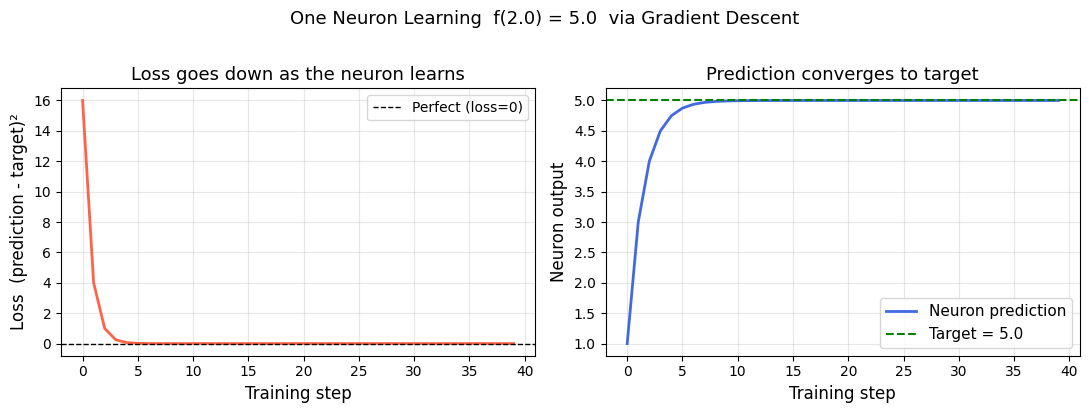

The left plot shows the loss going to zero.
The right plot shows the prediction approaching the target.
Both driven entirely by the chain rule through our 3-node graph.


In [7]:
# ─────────────────────────────────────────────────────────────────
# BONUS: Plot the loss going down so you can SEE the learning
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
%matplotlib inline

# Re-run training and collect loss at every step
w_val = 0.5
b_val = 0.0
x_val = 2.0
target_val = 5.0
lr = 0.05

loss_history       = []   # loss at each step
prediction_history = []   # prediction at each step

for step in range(40):
    # Forward
    x = make_node(x_val)
    w = make_node(w_val)
    b = make_node(b_val)
    xw     = mul(x, w)
    output = add(xw, b)
    loss   = squared_error(output, target_val)

    # Backward
    loss['grad'] = 1.0
    loss['backward']()
    output['backward']()
    xw['backward']()

    # Record BEFORE updating (so step 0 shows initial state)
    loss_history.append(loss['value'])
    prediction_history.append(output['value'])

    # Update
    w_val -= lr * w['grad']
    b_val -= lr * b['grad']


fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: loss over steps
axes[0].plot(loss_history, color='tomato', linewidth=2)
axes[0].set_xlabel('Training step', fontsize=12)
axes[0].set_ylabel('Loss  (prediction - target)²', fontsize=12)
axes[0].set_title('Loss goes down as the neuron learns', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1, label='Perfect (loss=0)')
axes[0].legend()

# Right: prediction over steps
axes[1].plot(prediction_history, color='royalblue', linewidth=2, label='Neuron prediction')
axes[1].axhline(target_val, color='green', linestyle='--', linewidth=1.5, label=f'Target = {target_val}')
axes[1].set_xlabel('Training step', fontsize=12)
axes[1].set_ylabel('Neuron output', fontsize=12)
axes[1].set_title('Prediction converges to target', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('One Neuron Learning  f(2.0) = 5.0  via Gradient Descent', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("The left plot shows the loss going to zero.")
print("The right plot shows the prediction approaching the target.")
print("Both driven entirely by the chain rule through our 3-node graph.")

---
## Summary: The Complete Mental Model

```
THE GRAPH IS JUST A MEMORY OF OPERATIONS

Every time you do:    z = a * b
A node is created:    z.value    = a.value * b.value
                      z.backward = "to backprop through me:
                                    a.grad += my_grad * b.value
                                    b.grad += my_grad * a.value"

BACKWARD IS JUST CALLING THOSE RECIPES IN REVERSE ORDER

Start with loss.grad = 1.0
Call loss.backward()    → fills output.grad
Call output.backward()  → fills xw.grad, b.grad
Call xw.backward()      → fills x.grad, w.grad

Each call is ONE application of the chain rule.

GRADIENT DESCENT IS JUST FOLLOWING THE GRADIENT DOWNHILL

w = w - lr * w.grad
b = b - lr * b.grad
```

### Where to go next

Now that you understand the core idea with plain numbers:

1. **Replace plain numbers with NumPy arrays** → one node now represents 1000 neurons instead of 1
2. **Add a topological sort** → so you don't have to call `.backward()` manually in order
3. **Add more operations** → relu, matmul, softmax — each is just a new backward recipe
4. **Wrap in classes** → `Module`, `Linear`, `SGD` — just organisation on top of the same idea

The full PyTorch notebook at the start of this session is now just those 4 extensions on top of what you just built.

In [10]:
# ─────────────────────────────────────────────────────────────────
# QUESTION 1: Why is the seed gradient 1?
# ─────────────────────────────────────────────────────────────────

# The seed is loss.grad = 1.0
# It means: dLoss/dLoss = 1
# "If the loss changes by 1, how much does the loss change?" → 1
# It's always 1 because it's the same variable.
# This is just the starting point that lets the chain rule begin.

loss = make_node(4.0)    # pretend this is our computed loss
loss['grad'] = 1.0       # seed: dLoss/dLoss = 1 always

# The chain rule then works backwards from this seed.
# Every other gradient is computed RELATIVE to this 1.0.
# If you seeded it with 2.0, all gradients would be doubled — meaningless.

print("Seed gradient demonstration:")
print(f"loss.grad = {loss['grad']}  ← always start with 1.0")
print("This means: 'the loss changes 1-for-1 with itself'")
print()


# ─────────────────────────────────────────────────────────────────
# QUESTION 2: Why is w.grad the uphill direction?
# ─────────────────────────────────────────────────────────────────

# w.grad tells you: "if I increase w by a tiny amount, 
#                    the loss changes by w.grad times that amount"
#
# So if w.grad = +6:  increasing w makes loss go UP   → bad, go DOWN
# If w.grad = -3:     increasing w makes loss go DOWN → we want to go that way
#
# The update rule:  w = w - lr * w.grad
#
# Case 1: w.grad is positive (uphill) → we subtract → w gets smaller → loss goes down ✓
# Case 2: w.grad is negative (already going down) → we subtract a negative
#         → w gets bigger → loss goes down ✓

print("Uphill/downhill demonstration:")
print()

w_val = 5.0
lr = 0.1

# Simulate: gradient is positive (we're going uphill)
w_grad_positive = 6.0
w_new = w_val - lr * w_grad_positive
print(f"w.grad = +{w_grad_positive}  (uphill — increasing w makes loss worse)")
print(f"  w = {w_val} - {lr} * {w_grad_positive} = {w_new}  ← w decreased, loss goes down ✓")
print()

# Simulate: gradient is negative (w should increase)
w_grad_negative = -3.0
w_new2 = w_val - lr * w_grad_negative
print(f"w.grad = {w_grad_negative}  (decreasing w would make loss worse)")
print(f"  w = {w_val} - {lr} * ({w_grad_negative}) = {w_new2}  ← w increased, loss goes down ✓")
print()


# ─────────────────────────────────────────────────────────────────
# QUESTION 3: Multiple inputs — training with x1 and x2
# ─────────────────────────────────────────────────────────────────
# 
# Now our neuron has TWO inputs: x1 and x2
# Formula:  output = x1*w1 + x2*w2 + b
#
# GRAPH:
#
#  [x1] ──┐
#           ├──► [mul1] ──┐
#  [w1] ──┘               ├──► [add1] ──┐
#                                        ├──► [add2] ──► output
#  [x2] ──┐               ┌─────────────┘
#           ├──► [mul2] ──┘
#  [w2] ──┘                              [b] ──────────┘
#
# The key: x1 and x2 are FIXED (from the dataset).
#          w1, w2, b are LEARNABLE.
# ─────────────────────────────────────────────────────────────────

# We need to reuse our functions from earlier
# (make sure you've run the earlier cells that define make_node, add, mul)

print("=" * 55)
print("MULTIPLE INPUTS: output = x1*w1 + x2*w2 + b")
print("=" * 55)
print()

# ── Fixed values (these represent our dataset) ────────────────
x1_val = 2.0    # first input feature
x2_val = 3.0    # second input feature  
target_val = 10.0  # what we want the output to be

# ── Learnable parameters (start with guesses) ─────────────────
w1_val = 0.5    # weight for x1
w2_val = 0.5    # weight for x2
b_val  = 0.0    # bias

lr = 0.01       # learning rate

print(f"Inputs:  x1={x1_val}, x2={x2_val}")
print(f"Target:  {target_val}")
print(f"Start:   w1={w1_val}, w2={w2_val}, b={b_val}")
print()
print(f"{'Step':>5}  {'w1':>7}  {'w2':>7}  {'b':>7}  {'output':>8}  {'loss':>10}")
print("-" * 52)

for step in range(60):

    # ── 1. Create fresh nodes each step ───────────────────────
    x1 = make_node(x1_val)    # input 1 (fixed, never changes)
    x2 = make_node(x2_val)    # input 2 (fixed, never changes)
    w1 = make_node(w1_val)    # weight 1 (learnable)
    w2 = make_node(w2_val)    # weight 2 (learnable)
    b  = make_node(b_val)     # bias (learnable)

    # ── 2. Forward pass: build the graph ──────────────────────
    x1w1   = mul(x1, w1)       # x1 * w1
    x2w2   = mul(x2, w2)       # x2 * w2
    sum1   = add(x1w1, x2w2)   # x1*w1 + x2*w2
    output = add(sum1, b)       # x1*w1 + x2*w2 + b
    loss   = squared_error(output, target_val)

    # ── 3. Backward pass ──────────────────────────────────────
    # Seed the loss
    loss['grad'] = 1.0

    # Walk in REVERSE order of operations
    # (last operation first, first operation last)
    loss['backward']()     # fills output.grad
    output['backward']()   # fills sum1.grad and b.grad
    sum1['backward']()     # fills x1w1.grad and x2w2.grad
    x1w1['backward']()     # fills x1.grad and w1.grad
    x2w2['backward']()     # fills x2.grad and w2.grad

    # ── 4. Update ONLY the learnable parameters ───────────────
    # We do NOT update x1 or x2 — those are inputs, not weights!
    w1_val = w1_val - lr * w1['grad']
    w2_val = w2_val - lr * w2['grad']
    b_val  = b_val  - lr * b['grad']

    # Print every 10 steps
    if step % 10 == 0 or step == 59:
        print(f"{step:>5}  {w1_val:>7.4f}  {w2_val:>7.4f}  {b_val:>7.4f}  "
              f"{output['value']:>8.4f}  {loss['value']:>10.6f}")

print("-" * 52)
print()
print(f"Final output: {output['value']:.4f}  (target was {target_val})")
print()

# ── Verify the learned weights make sense ─────────────────────
# We wanted: x1*w1 + x2*w2 + b = 10
# With x1=2, x2=3, there are many valid solutions.
# One is: w1=2, w2=2, b=0  because 2*2 + 3*2 + 0 = 10
# Another: w1=1, w2=1, b=5 because 2*1 + 3*1 + 5 = 10
# The gradient descent finds ONE of these — which one depends on
# the starting values and learning rate.
print("Final weights found:")
print(f"  w1={w1_val:.4f}, w2={w2_val:.4f}, b={b_val:.4f}")
print(f"  Check: {x1_val}*{w1_val:.3f} + {x2_val}*{w2_val:.3f} + {b_val:.3f} = "
      f"{x1_val*w1_val + x2_val*w2_val + b_val:.4f}")

Seed gradient demonstration:
loss.grad = 1.0  ← always start with 1.0
This means: 'the loss changes 1-for-1 with itself'

Uphill/downhill demonstration:

w.grad = +6.0  (uphill — increasing w makes loss worse)
  w = 5.0 - 0.1 * 6.0 = 4.4  ← w decreased, loss goes down ✓

w.grad = -3.0  (decreasing w would make loss worse)
  w = 5.0 - 0.1 * (-3.0) = 5.3  ← w increased, loss goes down ✓

MULTIPLE INPUTS: output = x1*w1 + x2*w2 + b

Inputs:  x1=2.0, x2=3.0
Target:  10.0
Start:   w1=0.5, w2=0.5, b=0.0

 Step       w1       w2        b    output        loss
----------------------------------------------------
    0   0.8000   0.9500   0.1500    2.5000   56.250000
   10   1.5425   2.0638   0.5213    9.7192    0.078845
   20   1.5703   2.1055   0.5352    9.9895    0.000111
   30   1.5714   2.1071   0.5357    9.9996    0.000000
   40   1.5714   2.1071   0.5357   10.0000    0.000000
   50   1.5714   2.1071   0.5357   10.0000    0.000000
   59   1.5714   2.1071   0.5357   10.0000    0.000000
---

In [11]:
# ─────────────────────────────────────────────────────────────────
# Training a single neuron on multiple examples
# Understanding: epoch, iteration, convergence
#
# Dataset: 5 points, all on the line  y = -4x + 13
#   x=1 → y=9,  x=2 → y=5,  x=3 → y=1,  x=4 → y=-3,  x=5 → y=-7
#
# The neuron must discover:  w = -4,  b = 13
# ─────────────────────────────────────────────────────────────────

# Make sure you have run the earlier cells that defined:
# make_node(), add(), mul(), squared_error()

# ── Dataset ───────────────────────────────────────────────────────
# Each pair is (input, expected_output)
dataset = [
    (1.0,  9.0),   # 1*(-4) + 13 =  9
    (2.0,  5.0),   # 2*(-4) + 13 =  5
    (3.0,  1.0),   # 3*(-4) + 13 =  1
    (4.0, -3.0),   # 4*(-4) + 13 = -3
    (5.0, -7.0),   # 5*(-4) + 13 = -7
]

num_examples = len(dataset)   # 5

# ── Learnable parameters ──────────────────────────────────────────
w_val = 0.0    # starting guess for weight
b_val = 0.0    # starting guess for bias

lr         = 0.01   # learning rate
num_epochs = 100    # how many full passes through the dataset

# ── Storage for plotting later ────────────────────────────────────
# We record the average loss at the END of each epoch
# (after the network has seen all examples once)
epoch_losses = []

print(f"Training on {num_examples} examples for {num_epochs} epochs")
print(f"Total iterations = {num_examples} × {num_epochs} = {num_examples * num_epochs}")
print(f"Goal: find w ≈ -4.0 and b ≈ 13.0")
print()
print(f"{'Epoch':>6}  {'Iteration':>10}  {'x':>5}  {'target':>7}  "
      f"{'output':>8}  {'loss':>8}  {'w':>8}  {'b':>8}")
print("-" * 72)

total_iterations = 0   # counts every single forward+backward+update

for epoch in range(1, num_epochs + 1):

    # We'll accumulate loss across all examples in this epoch
    # to compute the average loss for this epoch
    epoch_loss_sum = 0.0

    # ── One epoch = loop through every example once ───────────────
    for x_val, target_val in dataset:

        total_iterations += 1   # one more iteration done

        # ── Create fresh nodes for this example ───────────────────
        # We create new nodes each iteration because the graph
        # from the previous iteration still exists in memory.
        # Starting fresh keeps things clean.
        x = make_node(x_val)
        w = make_node(w_val)   # current weight (updated every iteration)
        b = make_node(b_val)   # current bias   (updated every iteration)

        # ── Forward pass ──────────────────────────────────────────
        xw     = mul(x, w)              # x * w
        output = add(xw, b)             # x*w + b
        loss   = squared_error(output, target_val)   # (output - target)²

        # ── Backward pass ─────────────────────────────────────────
        loss['grad'] = 1.0       # seed
        loss['backward']()       # fills output.grad
        output['backward']()     # fills xw.grad, b.grad
        xw['backward']()         # fills x.grad, w.grad

        # ── Update weights ────────────────────────────────────────
        w_val = w_val - lr * w['grad']
        b_val = b_val - lr * b['grad']

        # Accumulate loss for this epoch
        epoch_loss_sum += loss['value']

        # Print first 2 epochs in full detail so you can see
        # what's happening iteration by iteration
        if epoch <= 2:
            print(f"{epoch:>6}  {total_iterations:>10}  {x_val:>5.1f}  "
                  f"{target_val:>7.1f}  {output['value']:>8.4f}  "
                  f"{loss['value']:>8.4f}  {w_val:>8.4f}  {b_val:>8.4f}")

    # ── End of epoch ──────────────────────────────────────────────
    # Average loss = total loss across all examples / number of examples
    avg_loss = epoch_loss_sum / num_examples
    epoch_losses.append(avg_loss)

    # Print a summary line every 10 epochs (after the detail section)
    if epoch > 2 and epoch % 10 == 0:
        print(f"\n--- End of epoch {epoch} ---")
        print(f"    Avg loss = {avg_loss:.6f}")
        print(f"    w = {w_val:.4f}  (target: -4.0)")
        print(f"    b = {b_val:.4f}  (target: 13.0)")

print()
print("=" * 55)
print(f"Final w = {w_val:.4f}   (expected -4.0)")
print(f"Final b = {b_val:.4f}  (expected 13.0)")
print()
print("Verification — let's see what the neuron now predicts:")
print(f"{'x':>5}  {'predicted':>10}  {'actual':>8}  {'error':>8}")
print("-" * 36)
for x_val, target_val in dataset:
    pred = x_val * w_val + b_val
    print(f"{x_val:>5.1f}  {pred:>10.4f}  {target_val:>8.1f}  {abs(pred-target_val):>8.6f}")

Training on 5 examples for 100 epochs
Total iterations = 5 × 100 = 500
Goal: find w ≈ -4.0 and b ≈ 13.0

 Epoch   Iteration      x   target    output      loss         w         b
------------------------------------------------------------------------
     1           1    1.0      9.0    0.0000   81.0000    0.1800    0.1800
     1           2    2.0      5.0    0.5400   19.8916    0.3584    0.2692
     1           3    3.0      1.0    1.3444    0.1186    0.3377    0.2623
     1           4    4.0     -3.0    1.6133   21.2821   -0.0313    0.1700
     1           5    5.0     -7.0    0.0134   49.1881   -0.7327    0.0298
     2           6    1.0      9.0   -0.7029   94.1460   -0.5386    0.2238
     2           7    2.0      5.0   -0.8534   34.2621   -0.3045    0.3409
     2           8    3.0      1.0   -0.5725    2.4728   -0.2101    0.3724
     2           9    4.0     -3.0   -0.4681    6.4103   -0.4127    0.3217
     2          10    5.0     -7.0   -1.7416   27.6503   -0.9385    0.21

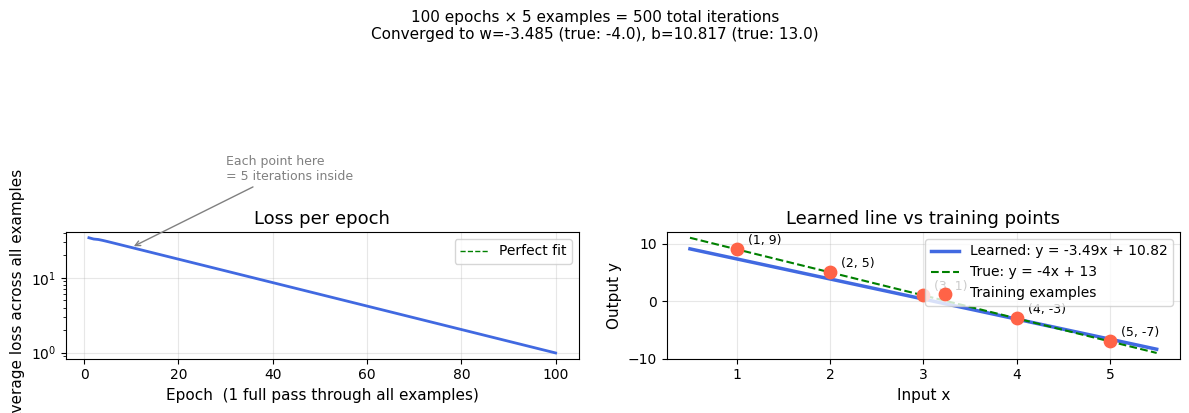

In [12]:
# ─────────────────────────────────────────────────────────────────
# Plot: see the difference between epoch-level and iteration-level
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: average loss per epoch ──────────────────────────────────
# Each point = one full pass through all 5 examples
# X axis counts epochs (1 to 100)
axes[0].plot(range(1, num_epochs + 1), epoch_losses,
             color='royalblue', linewidth=2)
axes[0].set_xlabel('Epoch  (1 full pass through all examples)', fontsize=11)
axes[0].set_ylabel('Average loss across all examples', fontsize=11)
axes[0].set_title('Loss per epoch', fontsize=13)
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='green', linestyle='--', linewidth=1, label='Perfect fit')
axes[0].legend()

# Annotate what an epoch is
axes[0].annotate('Each point here\n= 5 iterations inside',
                 xy=(10, epoch_losses[9]),
                 xytext=(30, epoch_losses[9] * 8),
                 fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='gray'),
                 color='gray')

# ── Right: what the learned line looks like vs the data ───────────
import numpy as np

x_line = np.linspace(0.5, 5.5, 100)
y_learned = w_val * x_line + b_val      # what our neuron learned
y_true    = -4.0  * x_line + 13.0      # the actual ground truth line

axes[1].plot(x_line, y_learned, color='royalblue',
             linewidth=2.5, label=f'Learned: y = {w_val:.2f}x + {b_val:.2f}')
axes[1].plot(x_line, y_true, color='green',
             linewidth=1.5, linestyle='--', label='True: y = -4x + 13')

# Plot the training points
xs = [d[0] for d in dataset]
ys = [d[1] for d in dataset]
axes[1].scatter(xs, ys, color='tomato', s=80, zorder=5,
                label='Training examples')

# Label each point with (x, y)
for x_pt, y_pt in dataset:
    axes[1].annotate(f'({x_pt:.0f}, {y_pt:.0f})',
                     (x_pt, y_pt),
                     textcoords='offset points',
                     xytext=(8, 4), fontsize=9)

axes[1].set_xlabel('Input x', fontsize=11)
axes[1].set_ylabel('Output y', fontsize=11)
axes[1].set_title('Learned line vs training points', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f'100 epochs × 5 examples = 500 total iterations\n'
    f'Converged to w={w_val:.3f} (true: -4.0), b={b_val:.3f} (true: 13.0)',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

In [13]:
# ─────────────────────────────────────────────────────────────────
# Batch Gradient Descent
#
# Same dataset, same neuron: output = x*w + b
# But now we process a BATCH of examples before each weight update
#
# Dataset: y = -4x + 13
# ─────────────────────────────────────────────────────────────────

# Make sure earlier cells (make_node, add, mul, squared_error) are run

dataset = [
    (1.0,  9.0),
    (2.0,  5.0),
    (3.0,  1.0),
    (4.0, -3.0),
    (5.0, -7.0),
    (6.0, -11.0),
    (7.0, -15.0),
    (8.0, -19.0),
]

num_examples = len(dataset)
batch_size   = 3      # how many examples per batch
lr           = 0.01
num_epochs   = 100

# ── Starting weights ──────────────────────────────────────────────
w_val = 0.0
b_val = 0.0

# ── Helper: split dataset into batches ───────────────────────────
def make_batches(data, batch_size):
    """
    Splits a list into chunks of size batch_size.

    Example: data=[A,B,C,D,E], batch_size=2
    Returns: [[A,B], [C,D], [E]]   ← last batch may be smaller
    """
    batches = []
    for start in range(0, len(data), batch_size):
        # slice from 'start' to 'start + batch_size'
        # if we go past the end, Python just takes what's left
        batch = data[start : start + batch_size]
        batches.append(batch)
    return batches

# Quick check
print("Batch structure preview:")
for i, batch in enumerate(make_batches(dataset, batch_size)):
    print(f"  Batch {i+1}: {batch}")
print()

# ─────────────────────────────────────────────────────────────────
# What changes vs single-example training:
#
# BEFORE (SGD):
#   for x, target in dataset:
#       forward → backward → UPDATE   ← update every example
#
# NOW (batch):
#   for batch in batches:
#       for x, target in batch:
#           forward → backward        ← accumulate gradients
#       AVERAGE gradients then UPDATE ← update once per batch
#
# The gradient accumulates naturally via += inside our backward().
# We just need to divide by batch size before updating.
# ─────────────────────────────────────────────────────────────────

epoch_losses  = []    # avg loss per epoch (for plotting)

print(f"{'Epoch':>6}  {'Batch':>6}  {'Examples seen':>14}  "
      f"{'Batch loss':>11}  {'w':>8}  {'b':>8}")
print("-" * 65)

for epoch in range(1, num_epochs + 1):

    batches          = make_batches(dataset, batch_size)
    epoch_loss_sum   = 0.0
    examples_seen    = 0

    for batch_idx, batch in enumerate(batches):

        # ── KEY STEP: reset accumulated gradients before each batch ──
        # We are about to accumulate gradients from multiple examples.
        # If we don't zero these out, gradients from the PREVIOUS batch
        # will add to this batch's gradients — wrong.
        w_grad_accum = 0.0   # will accumulate w.grad across the batch
        b_grad_accum = 0.0   # will accumulate b.grad across the batch
        batch_loss   = 0.0   # total loss across this batch

        # ── Loop through each example in the batch ───────────────────
        # Forward + backward for each, but DO NOT update weights yet
        for x_val, target_val in batch:

            examples_seen += 1

            # Create fresh nodes for this example
            x = make_node(x_val)
            w = make_node(w_val)   # same w_val for every example in batch
            b = make_node(b_val)   # same b_val for every example in batch

            # Forward pass
            xw     = mul(x, w)
            output = add(xw, b)
            loss   = squared_error(output, target_val)

            # Backward pass (fills w['grad'] and b['grad'] for THIS example)
            loss['grad'] = 1.0
            loss['backward']()
            output['backward']()
            xw['backward']()

            # Accumulate this example's gradients into running totals
            # This is the manual version of what += does automatically
            # in a proper tensor engine
            w_grad_accum += w['grad']
            b_grad_accum += b['grad']
            batch_loss   += loss['value']

        # ── After seeing all examples in the batch ────────────────────
        # Average the accumulated gradients by dividing by batch size
        n = len(batch)               # actual size (last batch may be smaller)
        w_grad_avg = w_grad_accum / n
        b_grad_avg = b_grad_accum / n

        # ONE weight update using the averaged gradient
        w_val = w_val - lr * w_grad_avg
        b_val = b_val - lr * b_grad_avg

        epoch_loss_sum += batch_loss

        # Print first 2 epochs in full so you can see batch structure
        if epoch <= 2:
            print(f"{epoch:>6}  {batch_idx+1:>6}  {examples_seen:>14}  "
                  f"{batch_loss/n:>11.4f}  {w_val:>8.4f}  {b_val:>8.4f}")

    # ── End of epoch ──────────────────────────────────────────────
    avg_loss = epoch_loss_sum / num_examples
    epoch_losses.append(avg_loss)

    if epoch > 2 and epoch % 20 == 0:
        print(f"\n--- Epoch {epoch} ---  avg loss={avg_loss:.6f}  "
              f"w={w_val:.4f}  b={b_val:.4f}")

print()
print("=" * 50)
print(f"Final w = {w_val:.4f}   (expected -4.0)")
print(f"Final b = {b_val:.4f}  (expected 13.0)")
print()
print(f"{'x':>5}  {'predicted':>10}  {'actual':>8}  {'error':>8}")
print("-" * 36)
for x_val, target_val in dataset:
    pred = x_val * w_val + b_val
    print(f"{x_val:>5.1f}  {pred:>10.4f}  {target_val:>8.1f}  "
          f"{abs(pred - target_val):>8.6f}")

Batch structure preview:
  Batch 1: [(1.0, 9.0), (2.0, 5.0), (3.0, 1.0)]
  Batch 2: [(4.0, -3.0), (5.0, -7.0), (6.0, -11.0)]
  Batch 3: [(7.0, -15.0), (8.0, -19.0)]

 Epoch   Batch   Examples seen   Batch loss         w         b
-----------------------------------------------------------------
     1       1               3      35.6667    0.1467    0.1000
     1       2               6      72.8243   -0.6920   -0.0567
     1       3               8     140.8845   -2.4715   -0.2917
     2       1               3     106.3092   -2.0825   -0.0870
     2       2               6      14.6990   -1.7581   -0.0170
     2       3               8      15.6736   -2.3389   -0.0930

--- Epoch 20 ---  avg loss=29.263340  w=-2.6896  b=2.6128

--- Epoch 40 ---  avg loss=17.489213  w=-2.9869  b=4.9699

--- Epoch 60 ---  avg loss=10.452415  w=-3.2168  b=6.7921

--- Epoch 80 ---  avg loss=6.246878  w=-3.3945  b=8.2008

--- Epoch 100 ---  avg loss=3.733442  w=-3.5319  b=9.2899

Final w = -3.5319   (expe

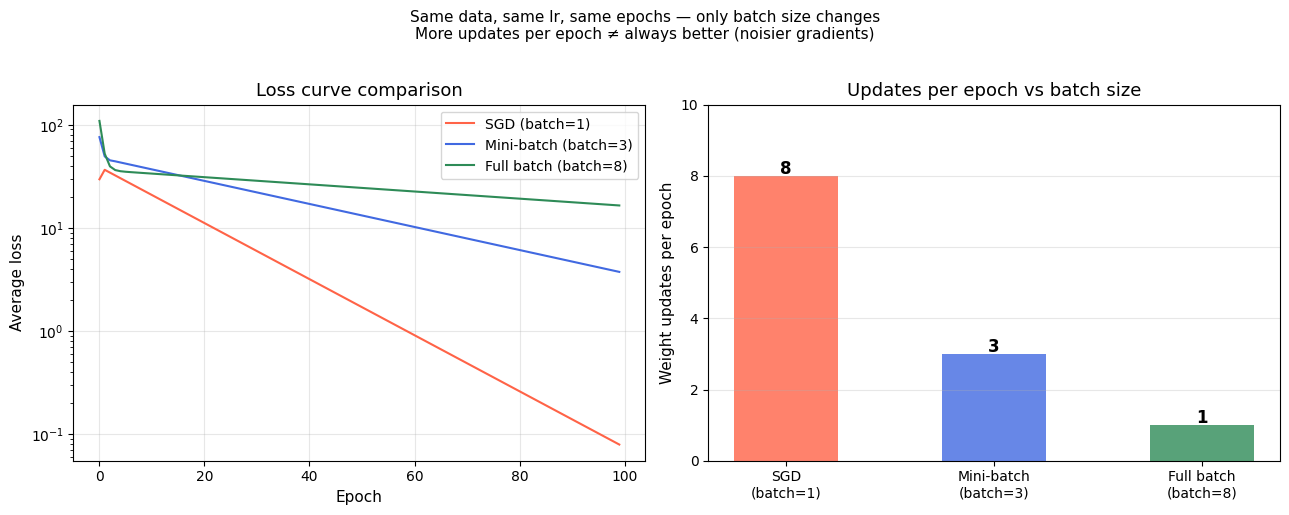


Final weights comparison (true: w=-4.0, b=13.0):
  SGD:        w=-3.9288,  b=12.4050
  Mini-batch: w=-3.5319,  b=9.2899
  Full batch: w=-2.4154,  b=4.0911


In [14]:
# ─────────────────────────────────────────────────────────────────
# Compare SGD vs Mini-batch vs Full-batch visually
# Run all three and plot their loss curves side by side
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
%matplotlib inline

def train(dataset, batch_size, lr=0.01, num_epochs=100):
    """
    Trains the neuron and returns the loss history.
    batch_size=1        → SGD
    batch_size=3        → mini-batch
    batch_size=len(data)→ full batch
    """
    w_val = 0.0
    b_val = 0.0
    epoch_losses = []

    for epoch in range(num_epochs):
        batches        = make_batches(dataset, batch_size)
        epoch_loss_sum = 0.0

        for batch in batches:
            w_grad_accum = 0.0
            b_grad_accum = 0.0
            batch_loss   = 0.0

            for x_val, target_val in batch:
                x = make_node(x_val)
                w = make_node(w_val)
                b = make_node(b_val)

                xw     = mul(x, w)
                output = add(xw, b)
                loss   = squared_error(output, target_val)

                loss['grad'] = 1.0
                loss['backward']()
                output['backward']()
                xw['backward']()

                w_grad_accum += w['grad']
                b_grad_accum += b['grad']
                batch_loss   += loss['value']

            n      = len(batch)
            w_val -= lr * (w_grad_accum / n)
            b_val -= lr * (b_grad_accum / n)
            epoch_loss_sum += batch_loss

        epoch_losses.append(epoch_loss_sum / len(dataset))

    return epoch_losses, w_val, b_val


# Train with three different batch sizes
losses_sgd,   w_sgd,   b_sgd   = train(dataset, batch_size=1)
losses_mini,  w_mini,  b_mini  = train(dataset, batch_size=3)
losses_full,  w_full,  b_full  = train(dataset, batch_size=len(dataset))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: loss curves ─────────────────────────────────────────────
axes[0].plot(losses_sgd,  label='SGD (batch=1)',            color='tomato',     linewidth=1.5)
axes[0].plot(losses_mini, label='Mini-batch (batch=3)',     color='royalblue',  linewidth=1.5)
axes[0].plot(losses_full, label='Full batch (batch=8)',     color='seagreen',   linewidth=1.5)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Average loss', fontsize=11)
axes[0].set_title('Loss curve comparison', fontsize=13)
axes[0].set_yscale('log')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Right: explanation of updates per epoch ────────────────────────
# Show how many weight updates each method does per epoch
methods = ['SGD\n(batch=1)', 'Mini-batch\n(batch=3)', 'Full batch\n(batch=8)']
updates = [8, 3, 1]   # updates per epoch for each method
colors  = ['tomato', 'royalblue', 'seagreen']

bars = axes[1].bar(methods, updates, color=colors, alpha=0.8, width=0.5)
axes[1].set_ylabel('Weight updates per epoch', fontsize=11)
axes[1].set_title('Updates per epoch vs batch size', fontsize=13)
axes[1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, updates):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 str(val),
                 ha='center', fontsize=12, fontweight='bold')

axes[1].set_ylim(0, 10)

plt.suptitle(
    'Same data, same lr, same epochs — only batch size changes\n'
    'More updates per epoch ≠ always better (noisier gradients)',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

print(f"\nFinal weights comparison (true: w=-4.0, b=13.0):")
print(f"  SGD:        w={w_sgd:.4f},  b={b_sgd:.4f}")
print(f"  Mini-batch: w={w_mini:.4f},  b={b_mini:.4f}")
print(f"  Full batch: w={w_full:.4f},  b={b_full:.4f}")